# Classification des images
L’objectif est de développer un modèle de classification multi-label basé uniquement sur les images.

### Rappel: Identification des labels

| Label | Catégorie        | Label | Catégorie         |
|-------|-----------------|-------|-------------------|
| 1     | Personne        | 11    | Bouche d'incendie |
| 2     | Vélo            | 13    | Feux signalisation|
| 3     | street    | 14    | borne à incendie    |
| 4     | Moto            | 15    | Banc              |
| 5     | Avion           | 16    | Oiseau            |
| 6     | Bus             | 17    | Chat              |
| 7     | Train           | 18    | Chien             |
| 8     | Truck/Camion | 19    | Cheval            |
| 9     | Bateau          |       |                   |
| 10    | Feux tricolores  |       |                   |


In [ ]:
import kagglehub
kagglehub.login()

Kaggle credentials set.
Kaggle credentials successfully validated.


In [ ]:

graceannexes_multimodality_classification_path = kagglehub.dataset_download('graceannexes/multimodality-classification')
graceannexes_final_multimodality_train_val_test_path = kagglehub.dataset_download('graceannexes/final-multimodality-train-val-test')
print('Data source import complete.')


100%|██████████| 399M/399M [00:24<00:00, 16.8MB/s]

Extracting files...


100%|██████████| 664k/664k [00:01<00:00, 543kB/s]

Extracting files...
Data source import complete.


In [ ]:
!ls /root/.cache/kagglehub/datasets/graceannexes/multimodality-classification/versions/1/COMP5329S1A2Dataset

data  test.csv	train.csv


In [ ]:
!ls /root/.cache/kagglehub/datasets/graceannexes/final-multimodality-train-val-test/versions/1/

test_split.csv	train_split.csv  val_split.csv


In [ ]:
import numpy as np
import pandas as pd
import os
import json
import matplotlib.pyplot as plt
import seaborn as sns
import csv
from collections import Counter
from tensorflow.keras.preprocessing.image import load_img
import re
import math
import ast
from PIL import Image
from collections import Counter

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


from sklearn.metrics import (multilabel_confusion_matrix,
                              classification_report,
                              f1_score, precision_score,
                              recall_score, hamming_loss)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv2D, BatchNormalization, Activation,
                                      MaxPooling2D, Flatten, Dense, Dropout,GlobalAveragePooling2D,Rescaling)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.metrics import AUC,Precision,Recall

from tensorflow.keras import Input
from tensorflow.keras.applications import EfficientNetB0,EfficientNetB5
from sklearn.metrics import accuracy_score, hamming_loss

from lime import lime_image
from PIL import Image
import os
from skimage.segmentation import mark_boundaries


from util_image import (load_and_preprocess,build_dataset,evaluate_model,plot_confusion_matrices,
                        plot_learning_curves,plot_predictions,plot_predictions_custom_seuils,find_best_thresholds,
                        downsample_pure_label1, load_image_for_lime, predict_fn, explain_all_active_labels, explain_image_for_label)

# Data Preparation

In [ ]:
data_dir ="/root/.cache/kagglehub/datasets/graceannexes/multimodality-classification/versions/1/COMP5329S1A2Dataset/data"
df_dir ="/root/.cache/kagglehub/datasets/graceannexes/final-multimodality-train-val-test/versions/1/"
df_train = pd.read_csv(df_dir+"/train_split.csv")
df_val = pd.read_csv(df_dir+"/val_split.csv")
df_test = pd.read_csv(df_dir+"/test_split.csv")

print("TRAIN DF")
display(df_train.head(3))

print("VAL DF")
display(df_val.head(3))

print("TEST DF")
display(df_test.head(3))

TRAIN DF


,ImageID,Labels,Caption,caption_length,nb_labels
0,3.jpg,"[8, 3, 13]",a black and silver clock tower at an intersect...,12,3
1,5.jpg,[1],A young man riding a skateboard into the air.,9,1
2,6.jpg,[5],A big airplane flying in the big blue sky,9,1


VAL DF


,ImageID,Labels,Caption,caption_length,nb_labels
0,0.jpg,[1],Woman in swim suit holding parasol on sunny day.,9,1
1,2.jpg,[1],They are brave for riding in the jungle on tho...,11,1
2,4.jpg,"[8, 3, 7]",A train coming to a stop on the tracks out side.,11,3


TEST DF


,ImageID,Labels,Caption,caption_length,nb_labels
0,1.jpg,"[1, 19]",A couple of men riding horses on top of a gree...,12,2
1,9.jpg,"[1, 18, 15]",A skate park next to a body of water and green...,12,3
2,12.jpg,"[1, 15]",A piece of cake and coffee are on an outdoor t...,11,2


# Data preprocessing

### Stratégie de gestion du déséquilibre

Afin de traiter le déséquilibre entre les classes, plusieurs approches seront explorées.

Dans un premier temps, deux méthodes complémentaires seront évaluées :
1. **Class weights** : pondération des classes inversement proportionnelle à leur fréquence, afin de pénaliser davantage les erreurs sur les classes minoritaires
2. **Seuils par classe** : ajustement des seuils de décision après entraînement, optimisés sur l’ensemble de validation pour améliorer les performances par classe

Dans un second temps, des techniques de rééchantillonnage seront également testées, telles que l’oversampling des classes minoritaires et l’undersampling des classes majoritaires.

L’objectif est d’identifier la stratégie la plus efficace pour améliorer les performances globales du modèle tout en réduisant le biais en faveur des classes dominantes.

In [ ]:
IMG_SIZE    = 224
BATCH_SIZE  = 32
ALL_LABELS  = [l for l in range(1, 20) if l != 12]
NUM_CLASSES = len(ALL_LABELS)


### Encodage des labels et preprocessing des images


In [ ]:
df_train["Labels"] = df_train["Labels"].apply(ast.literal_eval)
df_val["Labels"]   = df_val["Labels"].apply(ast.literal_eval)
df_test["Labels"]  = df_test["Labels"].apply(ast.literal_eval)

print(type(df_train["Labels"].iloc[0]))
print(df_train["Labels"].iloc[0])

label_matrix  = np.stack([labels_to_vector(l) for l in df_train["Labels"]])
class_counts  = label_matrix.sum(axis=0)
class_weights = len(df_train) / (NUM_CLASSES * class_counts)
class_weights = class_weights / class_weights.mean()
class_weights_dict = dict(enumerate(class_weights))

print("Class weights :")
for label, weight in zip(ALL_LABELS, class_weights):
    print(f"  Label {label:2d} : {weight:.3f}")

<class 'list'>
[8, 3, 13]
Class weights :
  Label  1 : 0.045
  Label  2 : 0.885
  Label  3 : 0.236
  Label  4 : 0.810
  Label  5 : 0.911
  Label  6 : 0.738
  Label  7 : 0.843
  Label  8 : 0.466
  Label  9 : 0.989
  Label 10 : 0.700
  Label 11 : 1.704
  Label 13 : 1.700
  Label 14 : 4.093
  Label 15 : 0.533
  Label 16 : 0.938
  Label 17 : 0.720
  Label 18 : 0.675
  Label 19 : 1.011


Les poids sont calculés selon la formule d'inversion de fréquence :

**class_weight = nb_images_train / (nb_classes × nb_occurrences_label)**

Puis normalisés en divisant par la moyenne pour centrer les poids autour de 1.0.

**Analyse des résultats :**

- Le label 1 obtient le poids le plus faible (0.045) car il est le plus dominant
- Le label 14 obtient le poids le plus élevé (4.093) — chaque
  erreur sur ce label sera ~90x plus pénalisée que le label 1 dans la loss.
- Les labels autour de 1.0 (label 19 : 1.011) correspondent aux labels dont
  la fréquence est proche de la moyenne du dataset.

Ce mécanisme est analogue au principe d'IDF (Inverse Document Frequency)
utilisé en NLP : les éléments rares reçoivent plus d'importance que les
éléments fréquents. Ici, ce rééquilibrage s'applique directement sur la
fonction de loss BinaryCrossentropy pendant l'entraînement, forçant le modèle
à accorder une attention proportionnelle à chaque classe indépendamment
de sa fréquence dans le dataset.

On construit les datasets et on verifie les shapes

In [ ]:
train_ds = build_dataset(df_train, data_dir, augment=False,  shuffle=True)
val_ds   = build_dataset(df_val,   data_dir, augment=False, shuffle=False)
test_ds  = build_dataset(df_test,  data_dir, augment=False, shuffle=False)

images, targets = next(iter(train_ds))
print(f"Shape images  : {images.shape}")
print(f"Shape targets : {targets.shape}")
print(f"Min / Max     : {images.numpy().min():.2f} / {images.numpy().max():.2f}")

Shape images  : (32, 224, 224, 3)
Shape targets : (32, 18)
Min / Max     : 0.00 / 255.00


Verification :
- Batches de shape (32, 224, 224, 3) — format attendu par les CNN
- Labels de shape (32, 18) — vecteurs binaires multi-label

On prend une image aléatoirement et on vérifie son format :


In [ ]:
img_path = os.path.join(data_dir, df_train.iloc[0]["ImageID"])

img_tensor, label = load_and_preprocess(
    img_path,
    labels_to_vector(df_train.iloc[0]["Labels"])
)

print(f"Type    : {type(img_tensor)}")
print(f"Shape   : {img_tensor.shape}")
print(f"Dtype   : {img_tensor.dtype}")
print(f"Min     : {img_tensor.numpy().min():.4f}")
print(f"Max     : {img_tensor.numpy().max():.4f}")
print(f"\nTenseur complet (canal R) :")
print(img_tensor.numpy()[:5, :5, 0])
print(f"\nTenseur complet (canal G) :")
print(img_tensor.numpy()[:5, :5, 1])
print(f"\nTenseur complet (canal B) :")
print(img_tensor.numpy()[:5, :5, 2])

Type    : <class 'tensorflow.python.framework.ops.EagerTensor'>
Shape   : (224, 224, 3)
Dtype   : <dtype: 'float32'>
Min     : 1.1479
Max     : 255.0000

Tenseur complet (canal R) :
[[136.24236 137.10715 138.17857 139.30357 140.5357 ]
 [137.66582 138.32397 138.93623 140.625   141.96428]
 [140.07397 140.25    141.32143 142.39285 143.46428]
 [142.01785 142.60715 143.67857 144.75    145.98215]
 [143.92857 144.03572 145.10715 146.41072 148.20152]]

Tenseur complet (canal G) :
[[131.24236 132.10715 133.17857 134.30357 135.5357 ]
 [132.66582 133.32397 133.93623 135.625   136.96428]
 [135.07397 135.25    136.32143 137.39285 138.46428]
 [137.01785 137.60715 138.67857 139.75    140.98215]
 [138.92857 139.03572 140.10715 141.41072 143.20152]]

Tenseur complet (canal B) :
[[128.24236 129.10715 130.17857 131.30357 132.5357 ]
 [129.66582 130.32397 130.93623 132.625   133.96428]
 [132.07397 132.25    133.32143 134.39285 135.46428]
 [134.01785 134.60715 135.67857 136.75    137.98215]
 [135.92857 136.

## Protocole d’évaluation

En classification multi-label, l'accuracy classique est inadaptée car elle
masque les performances sur les classes minoritaires.

### Métriques retenues

**Par classe :**
- **Precision** : parmi les labels prédits, combien sont corrects
- **Recall** : parmi les labels attendus, combien sont prédits
- **F1-score** : moyenne harmonique precision/recall — équilibre les deux
- **Matrice de confusion** : TN/FP/FN/TP par label

**Agrégées :**
- **F1 macro** : moyenne sur toutes les classes. C'est la métrique principale de comparaison entre modèles car il pénalise également les erreurs sur les classes rares et fréquentes.

### Seuil de décision
On choisi d'abord un seuil de 0.3 Pour que le modèle ne manque pas de prédire des classes sous représentées.


In [ ]:
y_train = np.stack([labels_to_vector(l) for l in df_train["Labels"]])
y_val   = np.stack([labels_to_vector(l) for l in df_val["Labels"]])
y_test  = np.stack([labels_to_vector(l) for l in df_test["Labels"]])

print(f"Shape y_val : {y_val.shape}")
print(f"Exemple     : {y_val[0]}")

Shape y_val : (2693, 18)
Exemple     : [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [ ]:
num_features = 32
width        = 224
height       = 224
channels     = 3
input_shape=(224, 224, 3)

## Baseline

Comme baseline, nous utilisons un réseau de neurones convolutionnel (CNN) simple.

L’architecture du modèle repose sur une succession de blocs convolutionnels suivis de couches denses.

En entrée, une étape de normalisation (rescaling) est appliquée afin de ramener les valeurs des pixels dans l’intervalle [0, 1]. Le modèle débute ensuite par un premier bloc convolutionnel composé de deux couches de convolution 2D avec des noyaux de taille 3×3 et un nombre de filtres élevé (4 × num_features), chacune suivie d’une couche de Batch Normalization et d’une activation ReLU. Ce bloc se termine par une couche de MaxPooling2D (2×2), permettant de réduire la dimension spatiale.

Un second bloc convolutionnel est ensuite ajouté, avec deux couches Conv2D (3×3) utilisant un nombre de filtres plus faible (2 × num_features), également suivies de Batch Normalization et d’activations ReLU, puis d’une couche de MaxPooling2D (2×2). Ce bloc permet d’affiner les représentations extraites tout en poursuivant la réduction de dimension.

Les cartes de caractéristiques sont ensuite aplaties (Flatten) afin d’être exploitées par des couches entièrement connectées. Un premier bloc dense est constitué d’une couche Dense (4 × num_features), suivie d’une Batch Normalization et d’une activation ReLU. Un second bloc dense, plus compact, est ajouté avec une couche Dense (2 × num_features), également suivie d’une Batch Normalization et d’une activation ReLU.

Enfin, la tête de classification est composée d’une couche Dense de sortie avec une activation sigmoïde.

In [ ]:
model_baseline = Sequential()

# Module 1
model_baseline.add(Rescaling(1./255, input_shape=input_shape))
model_baseline.add(Conv2D(2*2*num_features, kernel_size=(3, 3),
                           padding="same"))
model_baseline.add(BatchNormalization())
model_baseline.add(Activation("relu"))
model_baseline.add(Conv2D(2*2*num_features, kernel_size=(3, 3), padding="same"))
model_baseline.add(BatchNormalization())
model_baseline.add(Activation("relu"))
model_baseline.add(MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))

# Module 2
model_baseline.add(Conv2D(2*num_features, kernel_size=(3, 3), padding="same"))
model_baseline.add(BatchNormalization())
model_baseline.add(Activation("relu"))
model_baseline.add(Conv2D(2*num_features, kernel_size=(3, 3), padding="same"))
model_baseline.add(BatchNormalization())
model_baseline.add(Activation("relu"))
model_baseline.add(MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))


model_baseline.add(Flatten())

# Dense 2
model_baseline.add(Dense(2*2*num_features))
model_baseline.add(BatchNormalization())
model_baseline.add(Activation("relu"))

# Dense 3
model_baseline.add(Dense(2*num_features))
model_baseline.add(BatchNormalization())
model_baseline.add(Activation("relu"))

model_baseline.add(Dense(NUM_CLASSES, activation="sigmoid"))

model_baseline.compile(
    loss="binary_crossentropy",
    optimizer=Adam(),
    metrics=[
        tf.keras.metrics.AUC(name="auc", multi_label=True),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

model_baseline.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_2 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 224, 224, 128)  │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 224, 224, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_12 (Activation)      │ (None, 224, 224, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 224, 224, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 224, 224, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_13 (Activation)      │ (None, 224, 224, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 112, 112, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 112, 112, 64)   │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_14 (Activation)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_15 (Activation)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 200704)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │    25,690,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_16 (Activation)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_17 (Activation)      │ (None, 64)             │             

 Total params: 25,963,858 (99.04 MB)

 Trainable params: 25,962,706 (99.04 MB)

 Non-trainable params: 1,152 (4.50 KB)

In [ ]:
es = EarlyStopping(monitor='val_loss', patience = 5, mode = 'min',
  restore_best_weights=True)


history_baseline = model_baseline.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[es],
    class_weight=class_weights_dict
)

Epoch 1/20


2026-04-01 09:17:03.670177: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-01 09:17:03.827139: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-01 09:17:05.237250: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-01 09:17:05.415133: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-01 09:17:12.255049: E external/local_xla/xla/service

758/759 ━━━━━━━━━━━━━━━━━━━━ 0s 456ms/step - auc: 0.5871 - loss: 0.0742 - precision: 0.0755 - recall: 0.0555

2026-04-01 09:23:25.979760: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-01 09:23:26.135187: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-01 09:23:27.405443: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-01 09:23:27.580463: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-01 09:23:33.639341: E external/local_xla/xla/service

759/759 ━━━━━━━━━━━━━━━━━━━━ 437s 521ms/step - auc: 0.5872 - loss: 0.0741 - precision: 0.0755 - recall: 0.0554 - val_auc: 0.6568 - val_loss: 0.2847 - val_precision: 0.2018 - val_recall: 0.0055
Epoch 2/20
759/759 ━━━━━━━━━━━━━━━━━━━━ 358s 472ms/step - auc: 0.7201 - loss: 0.0466 - precision: 0.2866 - recall: 0.0153 - val_auc: 0.6097 - val_loss: 0.3143 - val_precision: 0.1339 - val_recall: 0.0162
Epoch 3/20
759/759 ━━━━━━━━━━━━━━━━━━━━ 358s 472ms/step - auc: 0.7594 - loss: 0.0400 - precision: 0.4456 - recall: 0.0467 - val_auc: 0.6765 - val_loss: 0.2487 - val_precision: 0.4597 - val_recall: 0.0655
Epoch 4/20
759/759 ━━━━━━━━━━━━━━━━━━━━ 359s 472ms/step - auc: 0.7952 - loss: 0.0326 - precision: 0.5745 - recall: 0.1238 - val_auc: 0.6904 - val_loss: 0.2551 - val_precision: 0.4241 - val_recall: 0.0961
Epoch 5/20
759/759 ━━━━━━━━━━━━━━━━━━━━ 359s 472ms/step - auc: 0.8467 - loss: 0.0211 - precision: 0.7067 - recall: 0.2871 - val_auc: 0.6704 - val_loss: 0.3217 - val_precision: 0.3144 - val_recall

In [ ]:
y_pred_proba_val, y_pred_val,baseline_report = evaluate_model(
    model_baseline, val_ds, y_val, threshold=0.3, split_name="Validation"
)

85/85 ━━━━━━━━━━━━━━━━━━━━ 13s 142ms/step

ÉVALUATION — Validation | seuil = 0.3

F1 macro     : 0.1326
F1 micro     : 0.3015
F1 weighted  : 0.3129
F1 samples   : 0.2614
Precision mac: 0.2608
Recall macro : 0.1377

Rapport par classe :
              precision    recall  f1-score   support

     Label 1       0.88      0.37      0.52      2052
     Label 2       0.14      0.14      0.14       105
     Label 3       0.38      0.05      0.09       392
     Label 4       0.18      0.11      0.14       114
     Label 5       0.35      0.08      0.13       102
     Label 6       0.86      0.10      0.17       125
     Label 7       0.22      0.46      0.30       109
     Label 8       0.17      0.09      0.12       199
     Label 9       0.40      0.02      0.04        94
    Label 10       0.33      0.01      0.01       132
    Label 11       0.11      0.04      0.06        54
    Label 13       0.10      0.19      0.13        54
    Label 14       0.00      0.00      0.00        23
    Lab


**Commentaire :**

- **Label 1 (majoritaire)** : bonne précision (0.88) mais recall limité (0.37), indiquant un modèle trop conservateur malgré un seuil de 0.3. Il obtient toutefois le meilleur F1 (0.52), influencé par le déséquilibre de classes.
- **Label 6** : comportement similaire, avec une précision élevée (0.86) mais un recall très faible (0.10), entraînant un F1 faible (0.17).
- **Labels rares** (Label 14, 9, 10) : largement négligés, faute d’exemples suffisants pour apprendre des caractéristiques discriminantes. Le F1 est nul pour le Label 14.
- **Label 7 — cas notable** : bien que sous-représenté, il présente un recall relativement élevé (0.46), suggérant que certaines caractéristiques visuelles sont plus facilement identifiables pour ce label.

L’écart marqué entre le F1 macro (0.13) et le F1 weighted (0.31) confirme un biais important en faveur des classes majoritaires. Ces résultats servent de point de référence pour évaluer les améliorations des modèles suivants.

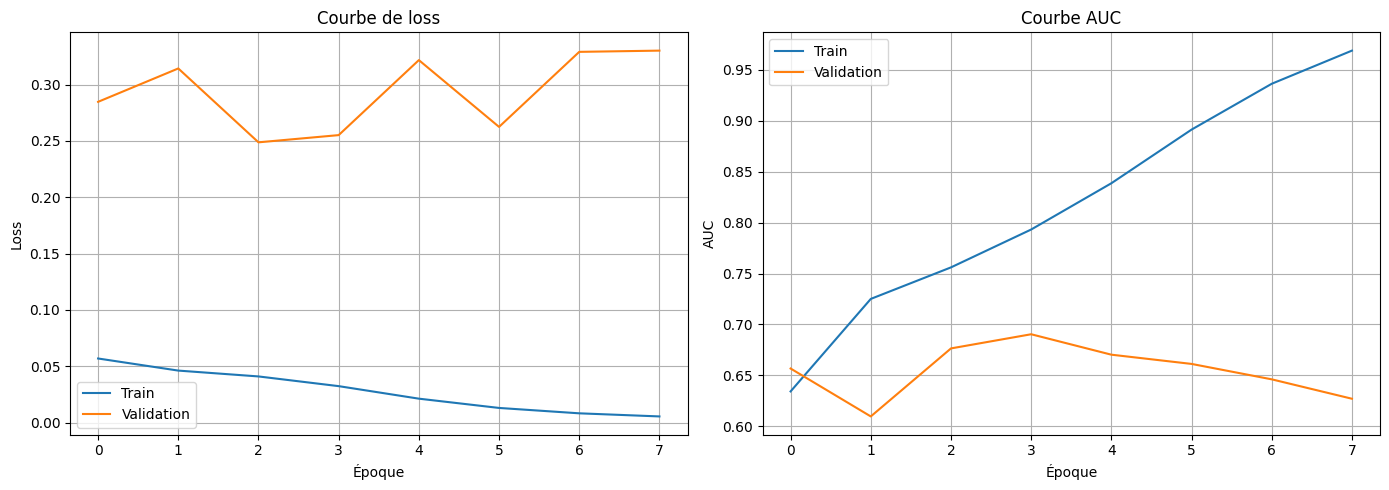

In [ ]:
plot_learning_curves(history_baseline)

**Commentaire :** Ces courbes révèlent un surapprentissage (overfitting) du modèle. La loss d'entraînement converge vers 0 tandis que la loss de validation augmente et oscille, et l'AUC de validation commence à décroître à partir de l'époque 3 alors que l'AUC d'entraînement continue de progresser. Augmenter le nombre d'époques ne ferait qu'accentuer ce phénomène.

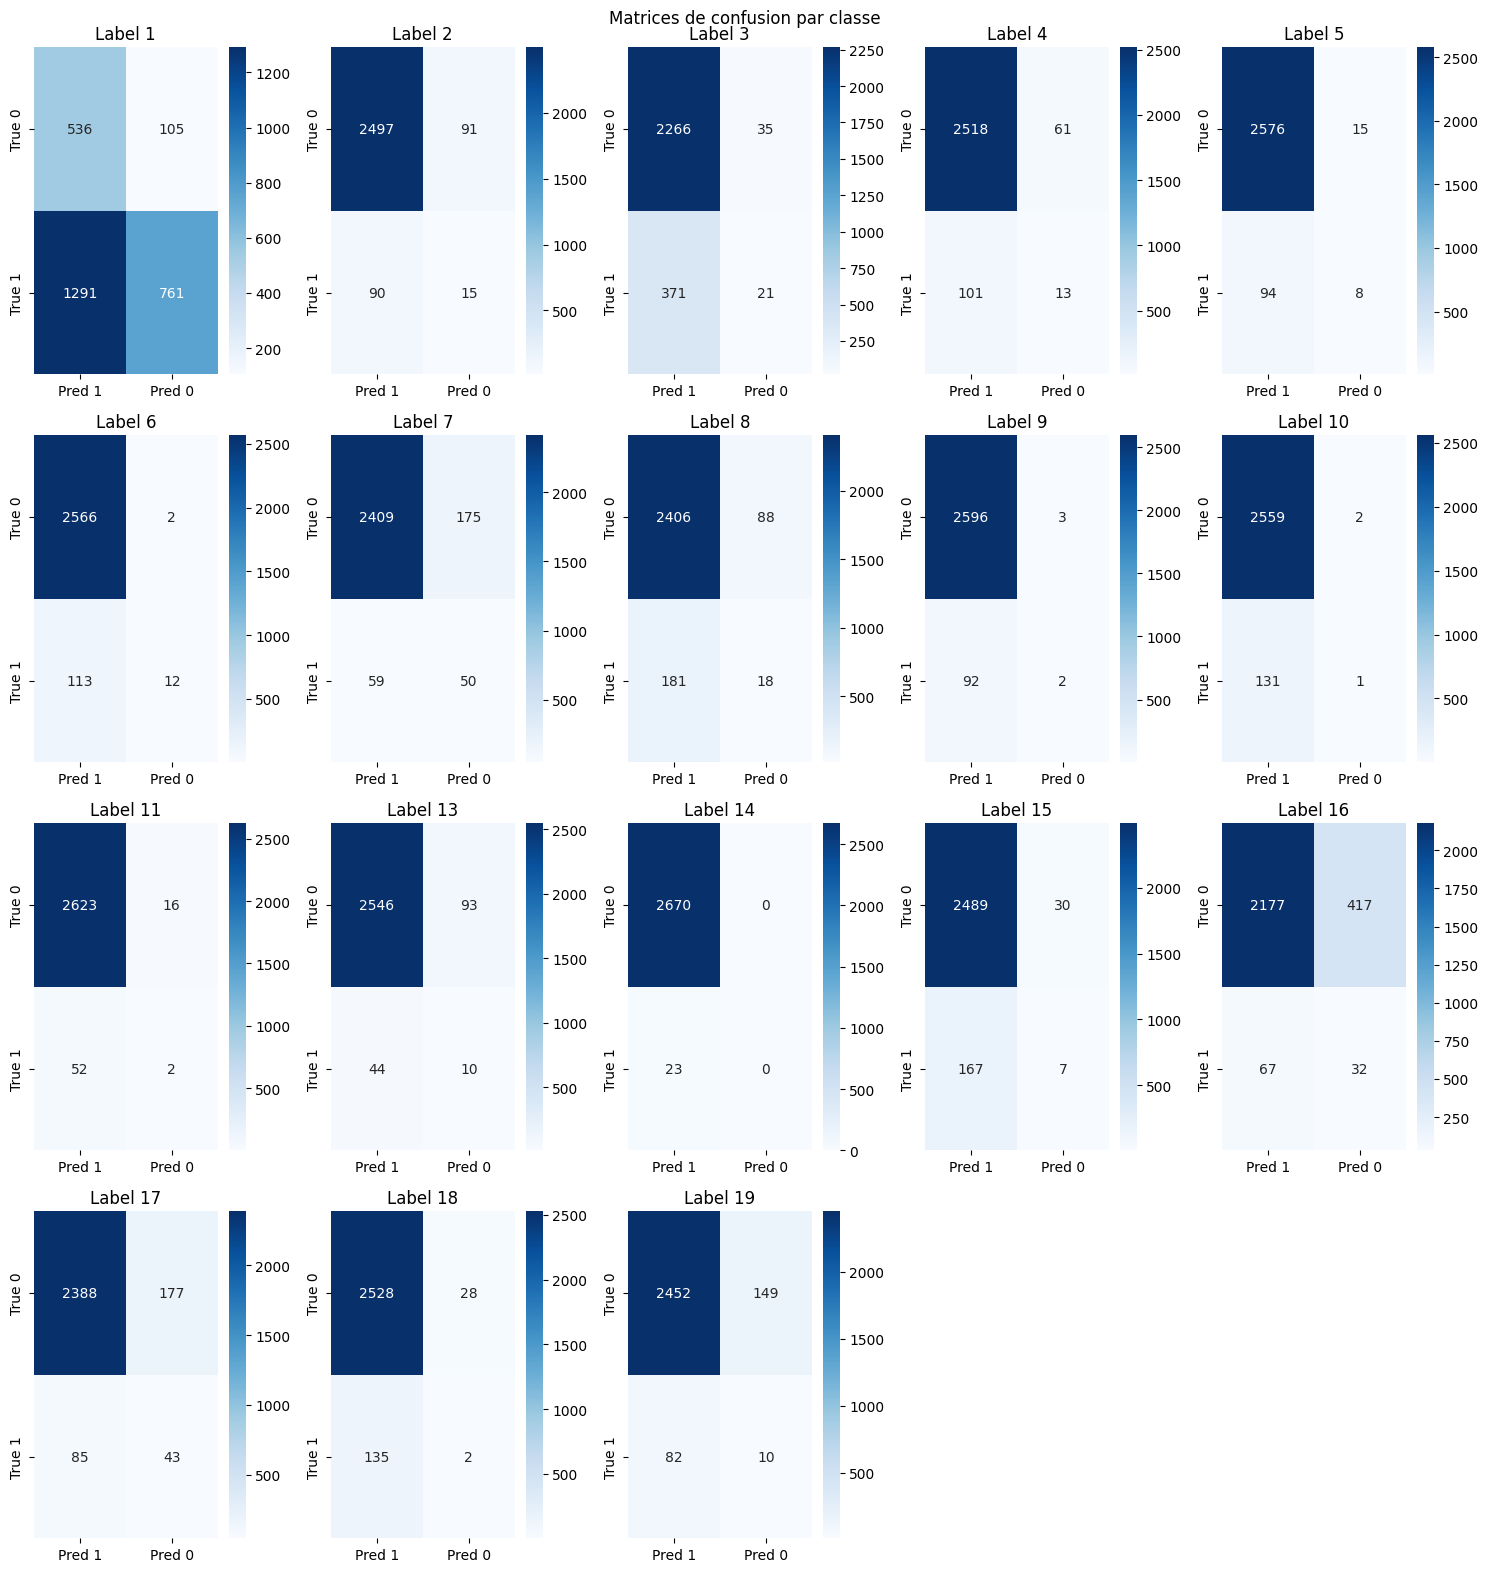

In [ ]:
plot_confusion_matrices(y_val, y_pred_val, n_labels=18)

**Commentaire :**

* Le modèle présente une tendance générale à sous-prédire, avec un recall faible sur la majorité des labels, en particulier les classes rares.

* Le Label 1 fait exception avec une sur-prédiction marquée (nombre élevé de faux positifs), liée à un seuil trop bas. À l’inverse, certains labels comme le Label 7 sont relativement bien appris malgré leur rareté.

* Plusieurs labels (9, 10, 11, 18) sont presque ignorés, avec très peu de prédictions correctes. Le Label 14 constitue un cas extrême, avec aucune détection.

* Enfin, certains labels (16, 17, 19) sont sur-prédits, entraînant une forte dégradation de la précision.

* Dans l’ensemble, le déséquilibre des classes reste la principale limite du modèle, les stratégies mises en place n’ayant pas permis de corriger efficacement les cas les plus rares.

# EfficientNetB0


L'architecture EfficientNet-B0 est un modèle de réseau de neurones convolutifs (CNN) compact conçu par Google, servant de base à la famille EfficientNet.
Avec un nombre de paramètres considérablement réduit, cette famille de modèles est efficace et offre de meilleurs résultats.



### Transfer learning ou fine-tuning

Nous choisissons d'appliquer un transfer learning sur ce modèle. En effet,
les images étant proches du domaine ImageNet, les features d’EfficientNetB0 sont directement exploitables sans ré-entraînement complet. De plus,  
le fine-tuning complet serait coûteux en calcul.
Enfin, le faible nombre d’exemples pour certains labels rend l’entraînement complet instable, alors que le transfer learning permet de s’appuyer sur des représentations déjà solides.

In [ ]:
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=input_shape
)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
base_model.trainable = False
inputs  = Input(shape=input_shape)
x       = base_model(inputs, training=False)
x       = GlobalAveragePooling2D()(x)
x       = BatchNormalization()(x)
x       = Dense(256, activation="relu")(x)
x       = Dropout(0.4)(x)
x       = Dense(128, activation="relu")(x)
x       = Dropout(0.3)(x)
outputs = Dense(NUM_CLASSES, activation="sigmoid")(x)

efficient_model = tf.keras.Model(inputs, outputs,
                                  name="efficientnet_b0")

efficient_model.compile(
    loss="binary_crossentropy",
    optimizer=Adam(learning_rate=1e-4),
    metrics=[AUC(name="auc", multi_label=True)]
)
efficient_model.summary()

Model: "efficientnet_b0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 18)             │         2,322 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,417,845 (16.85 MB)

 Trainable params: 365,714 (1.40 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

**COmmentaire :**

Le modèle repose sur une stratégie de transfer learning s'appuyant sur EfficientNetB0 pré-entraîné sur ImageNet comme backbone gelé. Les features visuelles extraites  sont agrégées par un GlobalAveragePooling2D, puis passées dans une tête de classification composée de deux couches denses avec dropout, et une couche de sortie à 18 neurones sigmoid.

**Note** : Pour l'entraînement, nous allons reconstruire le dataset en y ajoutant des images augmentées ciblant les labels rares (tel que le Label 14), afin d'augmenter le signal disponible pour ces classes sous-représentées.

Le downsampling du Label 1 est une opération sensible du fait des co-occurrences entre labels, supprimer des images portant le Label 1 risquerait d'appauvrir simultanément d'autres labels minoritaires qui lui sont associés, entraînant une perte d'information préjudiciable à l'entraînement. C'est une stratégie à utiliser en dernier recours.

Identifions les images avec un seul label rare.

In [ ]:
rare_labels = [2,4,5,6,7,8, 9, 11, 13, 14]

pure_rare = df_train[
    df_train["Labels"].apply(
        lambda x: len(x) == 1 and x[0] in rare_labels
    )
]

print(f"Images avec un seul label rare : {len(pure_rare)}")
print(pure_rare["Labels"].value_counts())

Images avec un seul label rare : 1717
Labels
[5]     451
[7]     382
[9]     173
[13]    164
[11]    148
[8]     131
[4]     107
[6]      81
[2]      44
[14]     36
Name: count, dtype: int64


Nous nous concentrerons sur sur les labels 2,4,6,8, 9, 11, 13, 14 car les labels 5 et 7 ont plus de représentations uniques


In [ ]:
def oversample_rare(dataframe, rare_labels, factor=3):
    rare_mask = dataframe["Labels"].apply(
        lambda x: any(l in x for l in rare_labels)
    )
    rare_df = dataframe[rare_mask]
    return pd.concat([dataframe] + [rare_df] * factor).reset_index(drop=True)

less_rare = [9,13,11,8,4]
more_rare = [6,2,14]

oversample_df = oversample_rare(df_train, less_rare, factor=3)
oversample_df = oversample_rare(oversample_df, more_rare, factor=4)
oversample_df = oversample_df.sample(frac=1, random_state=42).reset_index(drop=True)

In [ ]:
train_ds_augmented = build_dataset(oversample_df, data_dir, augment=True,  shuffle=True)

images, targets = next(iter(train_ds_augmented))
print(f"Shape images  : {images.shape}")
print(f"Shape targets : {targets.shape}")
print(f"Min / Max     : {images.numpy().min():.2f} / {images.numpy().max():.2f}")

Shape images  : (32, 224, 224, 3)
Shape targets : (32, 18)
Min / Max     : 0.00 / 255.00


In [ ]:
es = EarlyStopping(monitor='val_loss', patience = 10, mode = 'min',
  restore_best_weights=True)

history_eff = efficient_model.fit(
    train_ds_augmented,
    validation_data=val_ds,
    epochs=20,
    callbacks=es,
    class_weight=class_weights_dict
)

Epoch 1/20


KeyboardInterrupt: 

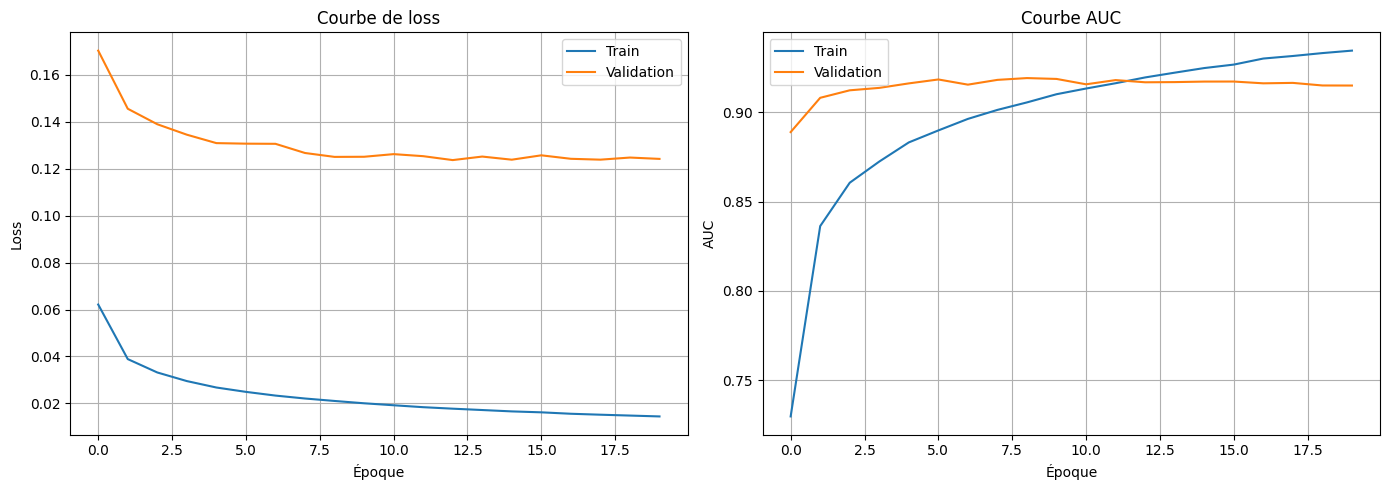

In [ ]:
plot_learning_curves(history_eff)

Ces courbes sont globalement satisfaisantes. Le modèle généralise bien, le transfer learning a clairement apporté une stabilité absente du baseline.  

In [ ]:
y_pred_proba_val_eff, y_pred_val_eff, eff_report = evaluate_model(
    efficient_model, val_ds, y_val, threshold=0.3, split_name="Validation"
)

85/85 ━━━━━━━━━━━━━━━━━━━━ 17s 116ms/step

ÉVALUATION — Validation | seuil = 0.3

F1 macro     : 0.5916
F1 micro     : 0.7101
F1 weighted  : 0.7302
F1 samples   : 0.7552
Precision mac: 0.5498
Recall macro : 0.6641

Rapport par classe :
              precision    recall  f1-score   support

     Label 1       0.97      0.84      0.90      2052
     Label 2       0.26      0.58      0.36       105
     Label 3       0.49      0.60      0.54       392
     Label 4       0.46      0.68      0.55       114
     Label 5       0.79      0.83      0.81       102
     Label 6       0.51      0.79      0.62       125
     Label 7       0.87      0.86      0.87       109
     Label 8       0.34      0.63      0.44       199
     Label 9       0.53      0.81      0.64        94
    Label 10       0.52      0.67      0.58       132
    Label 11       0.36      0.48      0.41        54
    Label 13       0.56      0.63      0.59        54
    Label 14       0.45      0.43      0.44        23
    Lab

**Commentaire :**
| Métrique | Baseline | EfficientNetB0 | Gain |
|---|---|---|---|
| F1 macro | 0.13 | **0.59** | +0.46 |
| F1 micro | 0.30 | **0.71** | +0.41 |
| F1 weighted | 0.31 | **0.73** | +0.42 |


Les performances progressent fortement sur l’ensemble des métriques, avec un gain particulièrement marqué en F1 macro (+0.46), traduisant une meilleure prise en compte des labels rares. La réduction de l’écart entre F1 macro et weighted confirme cette amélioration, notamment pour le Label 14 qui passe de 0.00 à 0.44.

Les labels les mieux maîtrisés (≥ 0.70) correspondent aux classes bien représentées ou efficacement rééquilibrées. Un groupe intermédiaire montre des performances correctes grâce à la loss pondérée, tandis que certains labels restent difficiles, soit en raison d’une sur-prédiction (Labels 2, 15), soit d’un manque de données (Labels 11, 14).

In [ ]:
plot_confusion_matrices(y_val, y_pred_val_eff, n_labels=18)

NameError: name 'y_pred_val_eff' is not defined

# EfficientNEtB5

![image.png](attachment:f1187062-4843-4491-a3ca-da09395cb16f.png)

C'est une Version plus profonde et plus large qu'EfficientNetB0. Avec 30M de paramètres, elle offre une capacité de représentation bien supérieure.

In [ ]:
base_model_b5 = EfficientNetB5(
    weights="imagenet",
    include_top=False,
    input_shape=input_shape
)

115263384/115263384 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
base_model_b5.trainable = False
inputs  = Input(shape=input_shape)
x       = base_model_b5(inputs, training=False)
x       = GlobalAveragePooling2D()(x)
x       = BatchNormalization()(x)
x       = Dense(256, activation="relu")(x)
x       = Dropout(0.4)(x)
x       = Dense(128, activation="relu")(x)
x       = Dropout(0.3)(x)
outputs = Dense(NUM_CLASSES, activation="sigmoid")(x)

efficientb5_model = tf.keras.Model(inputs, outputs,
                                  name="efficientnet_b5")

efficientb5_model.compile(
    loss="binary_crossentropy",
    optimizer=Adam(learning_rate=1e-4),
    metrics=[AUC(name="auc", multi_label=True)]
)
efficientb5_model.summary()

Model: "efficientnet_b5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb5 (Functional)     │ (None, 7, 7, 2048)     │    28,513,527 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 18)             │         2,322 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,081,481 (110.94 MB)

 Trainable params: 563,858 (2.15 MB)

 Non-trainable params: 28,517,623 (108.79 MB)

In [ ]:
es = EarlyStopping(monitor='val_loss', patience = 5, mode = 'min',
  restore_best_weights=True)

history_eff_b5 = efficientb5_model.fit(
    train_ds_augmented,
    validation_data=val_ds,
    epochs=20,
    callbacks=es,
    class_weight=class_weights_dict
)

Epoch 1/20
1672/1672 ━━━━━━━━━━━━━━━━━━━━ 376s 184ms/step - auc: 0.7385 - loss: 0.0616 - val_auc: 0.8801 - val_loss: 0.1708
Epoch 2/20
1672/1672 ━━━━━━━━━━━━━━━━━━━━ 237s 142ms/step - auc: 0.8332 - loss: 0.0384 - val_auc: 0.8958 - val_loss: 0.1507
Epoch 3/20
1672/1672 ━━━━━━━━━━━━━━━━━━━━ 236s 141ms/step - auc: 0.8564 - loss: 0.0327 - val_auc: 0.9022 - val_loss: 0.1455
Epoch 4/20
1672/1672 ━━━━━━━━━━━━━━━━━━━━ 237s 142ms/step - auc: 0.8711 - loss: 0.0290 - val_auc: 0.9042 - val_loss: 0.1407
Epoch 5/20
1672/1672 ━━━━━━━━━━━━━━━━━━━━ 262s 142ms/step - auc: 0.8813 - loss: 0.0265 - val_auc: 0.9063 - val_loss: 0.1352
Epoch 6/20
1672/1672 ━━━━━━━━━━━━━━━━━━━━ 246s 147ms/step - auc: 0.8904 - loss: 0.0245 - val_auc: 0.9073 - val_loss: 0.1373
Epoch 7/20
1672/1672 ━━━━━━━━━━━━━━━━━━━━ 237s 141ms/step - auc: 0.8992 - loss: 0.0226 - val_auc: 0.9082 - val_loss: 0.1360
Epoch 8/20
1672/1672 ━━━━━━━━━━━━━━━━━━━━ 237s 141ms/step - auc: 0.9039 - loss: 0.0212 - val_auc: 0.9088 - val_loss: 0.1336
Epoch 9/

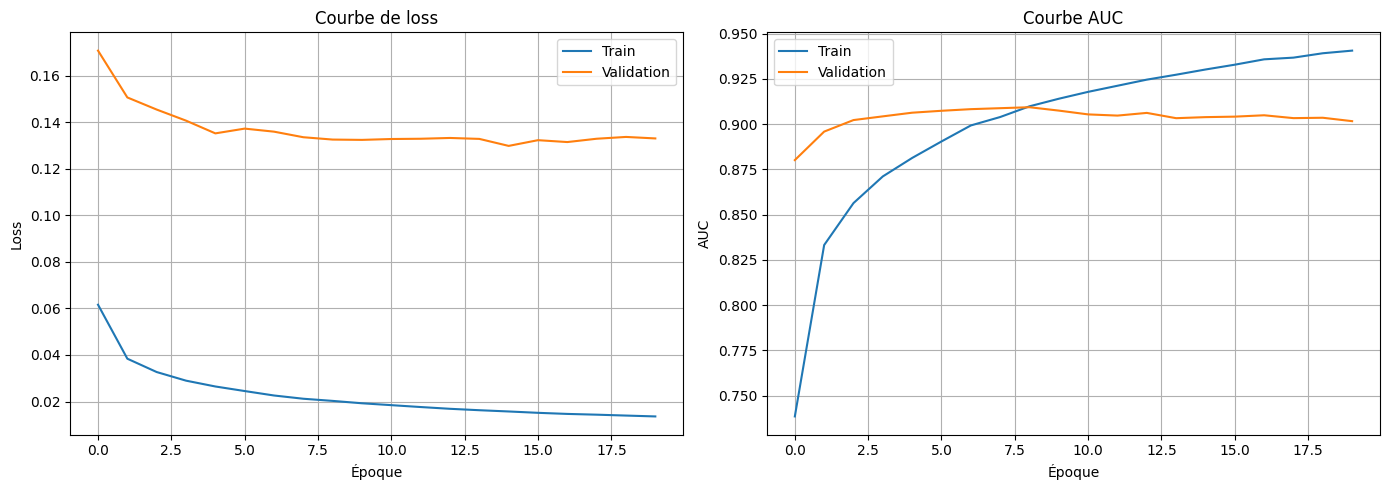

In [ ]:
plot_learning_curves(history_eff_b5)

**Commentaire :**

Un surapprentissage plus prononcé que sur B0 est observé. La loss de validation se stabilise rapidement, tandis que la loss d’entraînement continue de diminuer . L’écart entre les AUC-PR train et validation (~0.94 contre ~0.90) est également plus important que pour le B0.

Cela indique que la capacité plus élevée de B5 bénéficie surtout à l’apprentissage sur le train, sans amélioration réelle de la généralisation. La complexité du modèle apparaît donc excessive au regard du volume de données disponible.

In [ ]:
y_pred_proba_val_eff_b5, y_pred_val_eff_b5, eff_report = evaluate_model(
      efficientb5_model, val_ds, y_val, threshold=0.3, split_name="Validation"
  )

85/85 ━━━━━━━━━━━━━━━━━━━━ 39s 297ms/step

ÉVALUATION — Validation | seuil = 0.3

F1 macro     : 0.5919
F1 micro     : 0.7117
F1 weighted  : 0.7265
F1 samples   : 0.7539
Precision mac: 0.5577
Recall macro : 0.6476

Rapport par classe :
              precision    recall  f1-score   support

     Label 1       0.96      0.83      0.89      2052
     Label 2       0.27      0.49      0.35       105
     Label 3       0.51      0.59      0.55       392
     Label 4       0.52      0.65      0.58       114
     Label 5       0.77      0.83      0.80       102
     Label 6       0.50      0.74      0.60       125
     Label 7       0.80      0.86      0.83       109
     Label 8       0.37      0.57      0.45       199
     Label 9       0.58      0.82      0.68        94
    Label 10       0.50      0.58      0.54       132
    Label 11       0.42      0.54      0.47        54
    Label 13       0.45      0.61      0.52        54
    Label 14       0.50      0.48      0.49        23
    Lab

**Commentaire :**

| Métrique | Baseline | EfficientNetB0 | EfficientNetB5 |
|---|---|---|---|
| F1 macro | 0.13 | 0.59 | **0.59** |
| F1 micro | 0.30 | 0.71 | **0.71** |
| F1 weighted | 0.31 | 0.73 | **0.73** |


---

| Label | B0 F1 | B5 F1 | Δ |
|---|---|---|---|
| Label 14 | 0.44 | **0.52** | +0.08 |
| Label 11 | 0.41 | **0.46** | +0.05 |
| Label 9  | 0.64 | **0.69** | +0.05 |
| Label 17 | 0.74 | **0.69** | -0.05 |
| Label 1  | 0.90 | **0.89** | -0.01 |



EfficientNetB5 n’apporte pas d’amélioration globale par rapport à B0, avec des performances identiques sur les métriques principales (F1 macro, micro et weighted).  

On observe toutefois un léger gain sur certains labels rares (Label 14 et Label 11), mais celui-ci reste marginal au regard du surcoût computationnel induit.

Ces résultats suggèrent que la limite actuelle ne provient plus de l’architecture du modèle, mais plutôt des données. Les axes d’amélioration doivent donc se concentrer sur l’optimisation des seuils par label et un rééquilibrage plus poussé des classes critiques (notamment Labels 2 et 15).

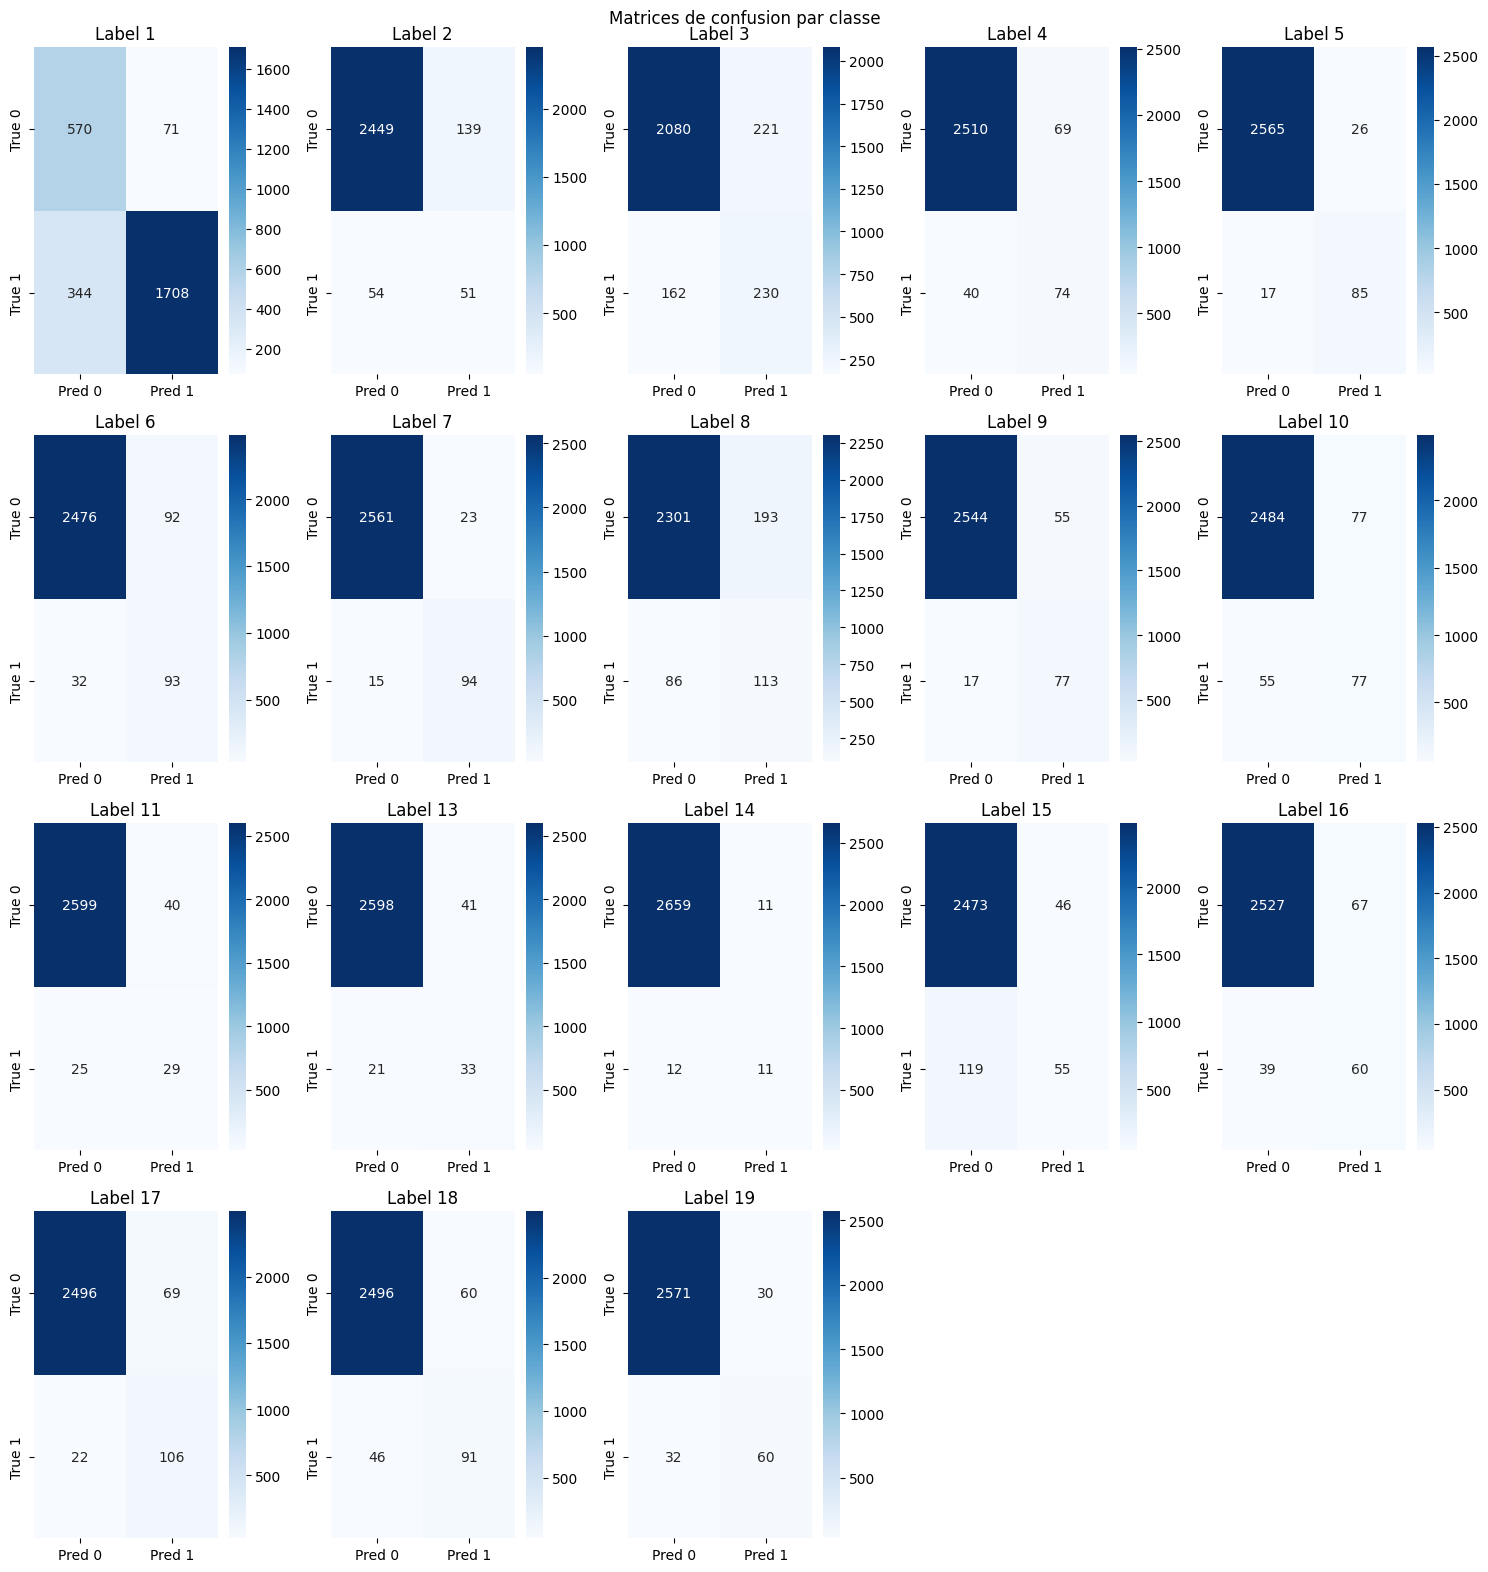

In [ ]:
plot_confusion_matrices(y_val, y_pred_val_eff_b5, n_labels=18)

**Commentaire :**
- **Label 2 (Vélo)** : nombreux FN et FP, principalement dus à la confusion avec le label 4 (Moto) et à la co-occurrence avec le label 1 (Personne).  
- **Labels 10, 14, 11** : confusion liée au contexte urbain commun (rue) plutôt qu’à la similarité des objets eux-mêmes.  
- **Label 3 (Street)** : erreurs élevées amplifiées par sa proximité visuelle avec les scènes urbaines des labels 10, 11 et 14.  
- **Labels 17, 18, 19 (animaux)** : erreurs liées au cadrage des images, les animaux étant parfois en arrière-plan

Nous sélectionnons aléatoirement quelques images du jeu de données ainsi que leurs prédictions associées afin d’analyser qualitativement le comportement du modèle.

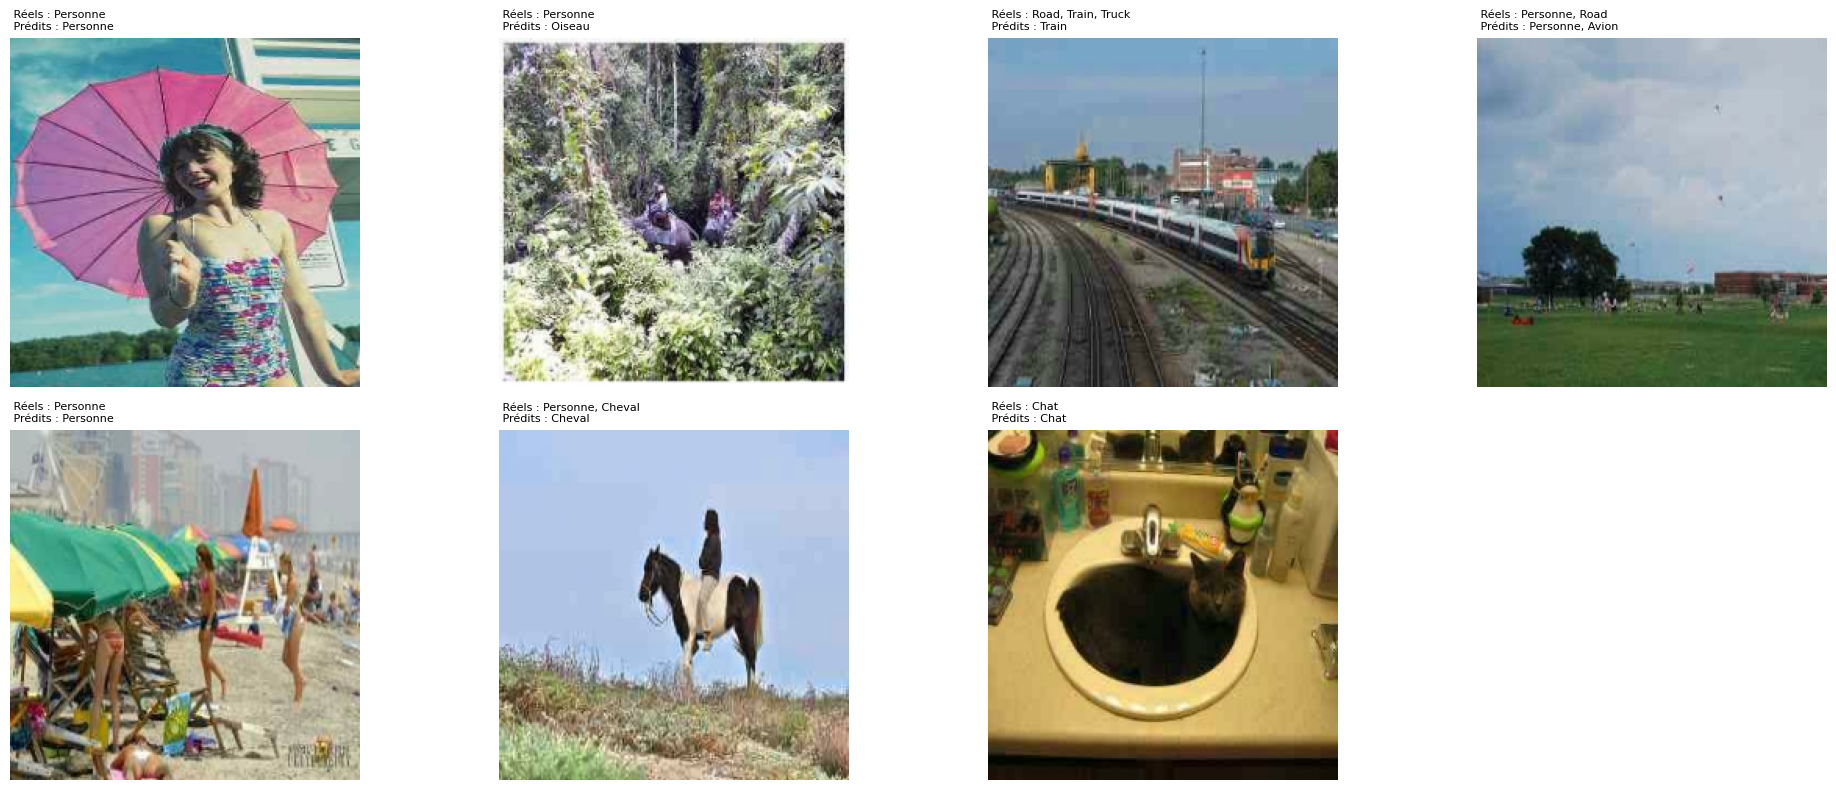

In [ ]:
plot_predictions([0,1,2,3,5,15,18], val_ds, y_pred_val_eff_b5, threshold=0.5)

**Commentaire**:
On observe plusieurs comportements intéressants du modèle.

Sur la 2ème image, le modèle confond une personne avec un oiseau, probablement en raison de la présence dominante de végétation (couleur verte), qu’il associe à ce label.

Sur la 3ème image, le train est correctement détecté, mais pas la route ni le camion, ces éléments étant moins centraux dans l’image.

Sur la 4ème image, le nombre de labels prédits correspond au nombre de labels réels. Cependant, le modèle prédit un avion, vraisemblablement influencé par la présence de nuages, suggérant une association forte avec le ciel.

Le modèle identifie correctement le chat (image 7) et la personne (image 5), mais échoue à détecter la personne présente sur le cheval, probablement en raison de sa position ou de son importance visuelle réduite.

Globalement, le modèle semble s’appuyer fortement sur des indices contextuels (couleurs, environnement) parfois au détriment des objets eux-mêmes.

# Pistes d'amélioration

Optimisons les seuils par label et apprecions les performances du modèle.

In [ ]:
best_thresholds, best_f1s = find_best_thresholds(y_val, y_pred_proba_val_eff_b5)

NameError: name 'y_pred_proba_val_eff_b5' is not defined

In [ ]:
def predict_with_thresholds(y_pred_probs, thresholds):

    y_pred = np.zeros_like(y_pred_probs, dtype=int)
    for label_idx, t in enumerate(thresholds):
        y_pred[:, label_idx] = (y_pred_probs[:, label_idx] >= t).astype(int)
    return y_pred

# y_pred_optimized = predict_with_thresholds(y_pred_proba_val_eff_b5, best_thresholds)

In [ ]:

y_pred_global = (y_pred_val_eff_b5 >= 0.3).astype(int)

print("=== Seuil global 0.3 ===")
print(classification_report(y_val, y_pred_global,target_names=[f"Label {l}" for l in ALL_LABELS]))

print("=== Seuils optimisés par label ===")
print(classification_report(y_val, y_pred_optimized, target_names=[f"Label {l}" for l in ALL_LABELS]))

=== Seuil global 0.3 ===
              precision    recall  f1-score   support

     Label 1       0.96      0.83      0.89      2052
     Label 2       0.27      0.49      0.35       105
     Label 3       0.51      0.59      0.55       392
     Label 4       0.52      0.65      0.58       114
     Label 5       0.77      0.83      0.80       102
     Label 6       0.50      0.74      0.60       125
     Label 7       0.80      0.86      0.83       109
     Label 8       0.37      0.57      0.45       199
     Label 9       0.58      0.82      0.68        94
    Label 10       0.50      0.58      0.54       132
    Label 11       0.42      0.54      0.47        54
    Label 13       0.45      0.61      0.52        54
    Label 14       0.50      0.48      0.49        23
    Label 15       0.54      0.32      0.40       174
    Label 16       0.47      0.61      0.53        99
    Label 17       0.61      0.83      0.70       128
    Label 18       0.60      0.66      0.63       137
  

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



**Commentaire :**
| Métrique | Seuil 0.3 | Seuils optimisés | Gain |
|---|---|---|---|
| F1 macro | 0.59 | **0.65** | +0.06 |
| F1 micro | 0.71 | **0.76** | +0.05 |
| Précision macro | 0.56 | **0.73** | +0.17 |
| Recall macro | 0.65 | **0.59** | -0.06 |

* la précision macro progresse de +0.17 au prix d'un léger recul du recall. Par contre, on observe des gains notables sur Labels 6 (+0.14), 13 (+0.15), 16 (+0.10).

* Label 1 : seuil retenu à 0.10. le modèle reste peu confiant sur la classe majoritaire.
* Labels 2, 8, 15 (F1 < 0.50) : problème structurel, non résolu par le seuil.
On pourrait envisager d'augmenter l'oversampling de ces classes.

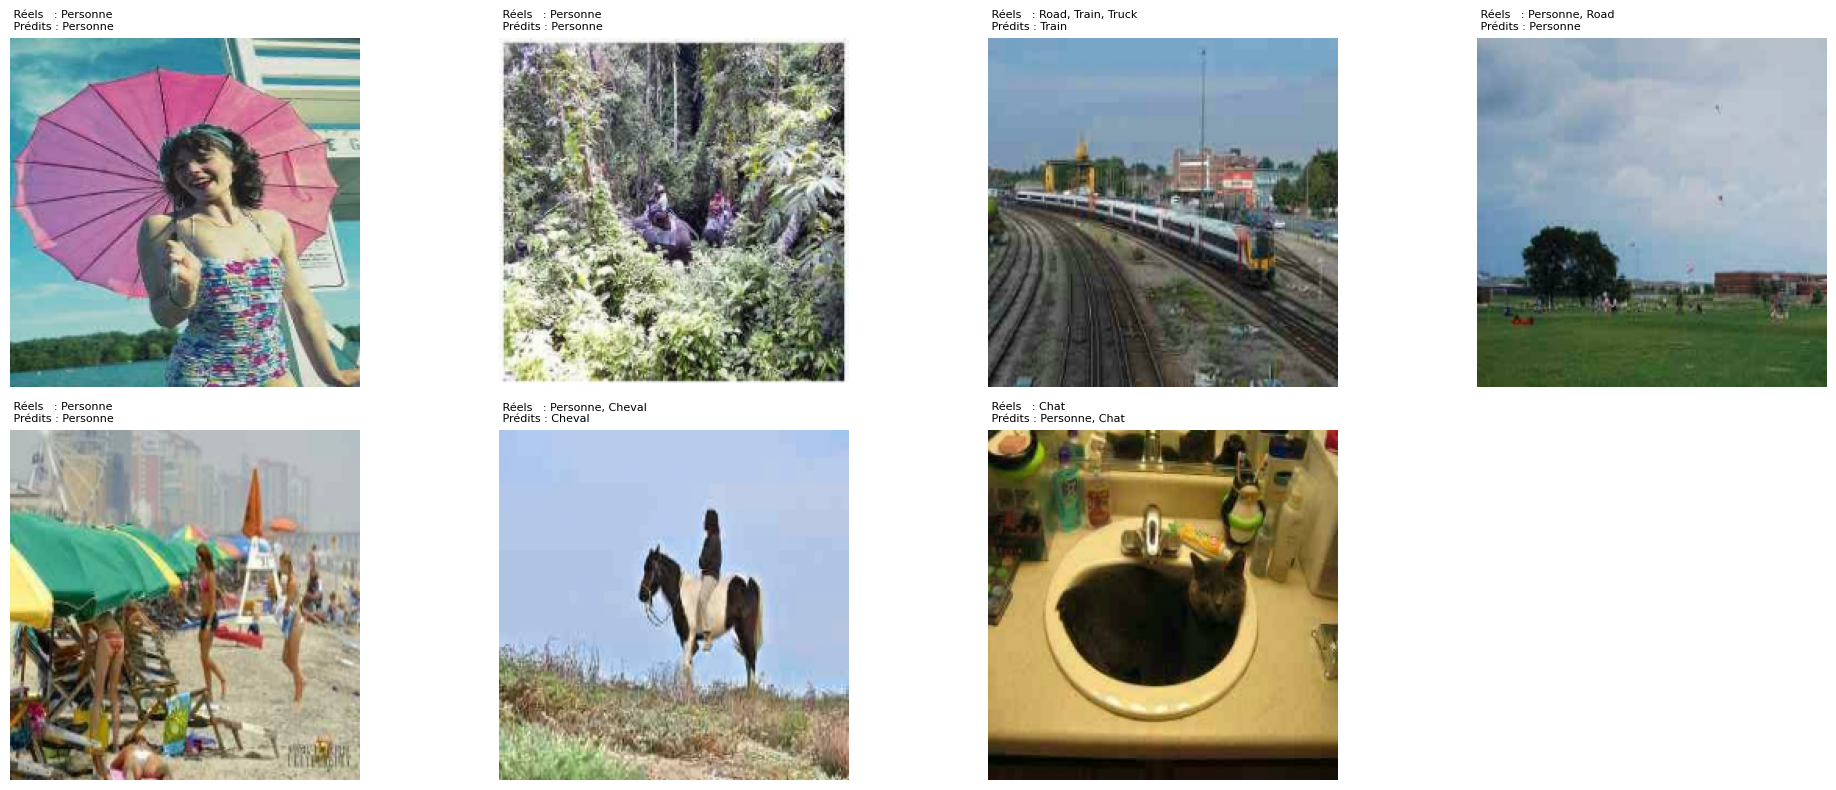

In [ ]:
plot_predictions_custom_seuils([0,1,2,3,5,15,18], val_ds, y_pred_optimized, best_thresholds)

**Commentaire :**

Le seuil optimal calculé pour le Label 1 (Personne) était très faible (**0.10**), entraînant de nombreux faux positifs. Ce comportement s'explique par le déséquilibre : le modèle attribue une probabilité non nulle à presque toutes les images pour ce label dominant. Un seuil plus élevé sera appliqué manuellement pour limiter la sur-prédiction.

In [ ]:


exact_matches      = np.all(y_true == y_pred_optimized, axis=1)
n_exact            = exact_matches.sum()
exact_match_ratio  = exact_matches.mean()

print(f"Exact Match         : {n_exact} / {len(y_true)}")
print(f"Exact Match Ratio   : {exact_match_ratio:.4f}")
print(f"Hamming Loss        : {hamming_loss(y_true, y_pred_optimized):.4f}")

exact_indices = np.where(exact_matches)[0]
print(f"\n→ {len(exact_indices)} prédictions parfaites trouvées")

plot_predictions(
    indices    = exact_indices[:8].tolist(),
    val_ds     = val_ds,
    y_pred     = y_pred_probs,
    thresholds = best_thresholds
)

wrong_indices = np.where(~exact_matches)[0]
print(f"\n→ {len(wrong_indices)} prédictions imparfaites")

plot_predictions(
    indices    = wrong_indices[:8].tolist(),
    val_ds     = val_ds,
    y_pred     = y_pred_probs,
    thresholds = best_thresholds
)

# Choix du modèle et amélioration

### Résumé

| Modèle | F1 macro | F1 weighted |
|---|---|---|
| Baseline CNN | 0.13 | 0.31 |
| EfficientNetB0 | 0.59 | 0.73 |
| EfficientNetB5 | 0.60 | 0.73 |

Les modèles EfficientNet (B0 et B5) surpassent largement la baseline CNN, avec un gain significatif en F1 macro (de 0.13 à ~0.60) et en F1 weighted (de 0.31 à 0.73).

Les principales améliorations proviennent de la combinaison de plusieurs stratégies : loss pondérée, oversampling ciblé des labels rares et optimisation des seuils par label (+0.06 en F1 macro).

**Modèle retenu : EfficientNetB0** — des performances équivalentes à B5 pour un coût computationnel nettement inférieur. Les limites actuelles étant liées aux données et au post-traitement, l’augmentation de la complexité du modèle n’apporte pas de bénéfice significatif.

In [ ]:
pure = df_train["Labels"].apply(lambda x: len(x) == 1 and x[0] == 1)
print(f"Label 1 pur : {pure.sum()} / {len(df_train)}")

Label 1 pur : 11443 / 24284


In [ ]:
train_df_balanced = downsample_pure_label1(df_train, frac=0.3)

less_rare = [9, 13, 11, 8, 4]
more_rare = [6, 2, 14]

oversample_df = oversample_rare(train_df_balanced, less_rare, factor=3)
oversample_df = oversample_rare(oversample_df, more_rare, factor=4)
oversample_df = oversample_df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Taille finale du dataset : {len(oversample_df)}")

train_ds_augmented = build_dataset(oversample_df, data_dir, augment=True,  shuffle=True)

print(f"Taille finale du dataset augmenté : {len(train_ds_augmented)}")

images, targets = next(iter(train_ds_augmented))
print(f"Shape images  : {images.shape}")
print(f"Shape targets : {targets.shape}")
print(f"Min / Max     : {images.numpy().min():.2f} / {images.numpy().max():.2f}")




Label 1 pur avant  : 11443
Label 1 pur après  : 3433
Reste (inchangé)   : 12841
Total avant        : 24284
Total après        : 16274
Taille finale du dataset : 45474
Taille finale du dataset augmenté : 1422
Shape images  : (32, 224, 224, 3)
Shape targets : (32, 18)
Min / Max     : 0.00 / 255.00


In [ ]:
es = EarlyStopping(monitor='val_loss', patience = 10, mode = 'min',
  restore_best_weights=True)

history_eff_final = efficient_model.fit(
    train_ds_augmented,
    validation_data=val_ds,
    epochs=20,
    callbacks=es,
    class_weight=class_weights_dict
)

Epoch 1/20
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 159s 89ms/step - auc: 0.6998 - loss: 0.0792 - val_auc: 0.8668 - val_loss: 0.2127
Epoch 2/20
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 91s 64ms/step - auc: 0.8204 - loss: 0.0477 - val_auc: 0.8912 - val_loss: 0.1799
Epoch 3/20
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 92s 65ms/step - auc: 0.8464 - loss: 0.0403 - val_auc: 0.8984 - val_loss: 0.1643
Epoch 4/20
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 91s 64ms/step - auc: 0.8607 - loss: 0.0358 - val_auc: 0.9043 - val_loss: 0.1550
Epoch 5/20
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 144s 65ms/step - auc: 0.8714 - loss: 0.0328 - val_auc: 0.9046 - val_loss: 0.1508
Epoch 6/20
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 89s 63ms/step - auc: 0.8791 - loss: 0.0303 - val_auc: 0.9058 - val_loss: 0.1501
Epoch 7/20
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 92s 64ms/step - auc: 0.8864 - loss: 0.0282 - val_auc: 0.9069 - val_loss: 0.1443
Epoch 8/20
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 89s 63ms/step - auc: 0.8920 - loss: 0.0267 - val_auc: 0.9067 - val_loss: 0.1464
Epoch 9/20
1422/1422 ━

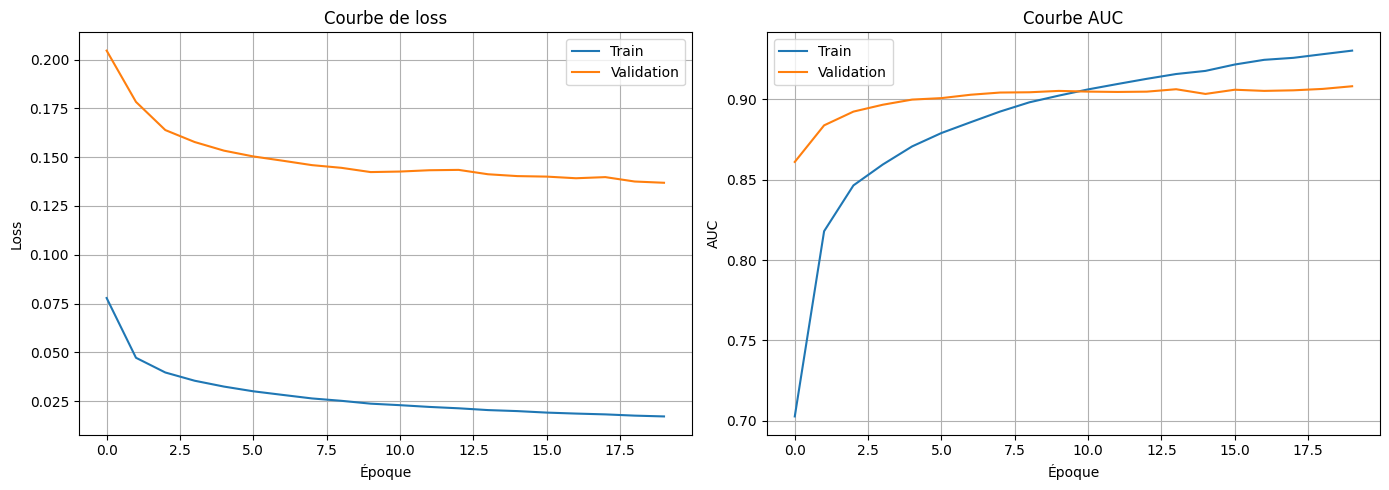

In [ ]:
plot_learning_curves(history_eff_final)

In [ ]:
y_pred_proba_val, y_pred_val, _ = evaluate_model(
      efficient_model, val_ds, y_val, threshold=0.3, split_name="Validation"
  )

85/85 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step

ÉVALUATION — Validation | seuil = 0.3

F1 macro     : 0.5836
F1 micro     : 0.6884
F1 weighted  : 0.7163
F1 samples   : 0.7161
Precision mac: 0.5252
Recall macro : 0.6832

Rapport par classe :
              precision    recall  f1-score   support

     Label 1       0.97      0.80      0.88      2052
     Label 2       0.28      0.59      0.38       105
     Label 3       0.44      0.64      0.52       392
     Label 4       0.49      0.71      0.58       114
     Label 5       0.83      0.84      0.84       102
     Label 6       0.48      0.78      0.59       125
     Label 7       0.86      0.86      0.86       109
     Label 8       0.34      0.68      0.45       199
     Label 9       0.46      0.85      0.59        94
    Label 10       0.56      0.64      0.60       132
    Label 11       0.32      0.52      0.39        54
    Label 13       0.60      0.63      0.61        54
    Label 14       0.41      0.48      0.44        23
    Label

In [ ]:
best_thresholds, best_f1s = find_best_thresholds(y_val, y_pred_proba_val)
best_thresholds[0] = max(best_thresholds[0], 0.3)

Label  1 - seuil optimal : 0.10 | F1 : 0.9132
Label  2 - seuil optimal : 0.65 | F1 : 0.4598
Label  3 - seuil optimal : 0.40 | F1 : 0.5192
Label  4 - seuil optimal : 0.65 | F1 : 0.6768
Label  5 - seuil optimal : 0.50 | F1 : 0.8629
Label  6 - seuil optimal : 0.55 | F1 : 0.7317
Label  7 - seuil optimal : 0.45 | F1 : 0.8774
Label  8 - seuil optimal : 0.55 | F1 : 0.4934
Label  9 - seuil optimal : 0.70 | F1 : 0.6916
Label 10 - seuil optimal : 0.40 | F1 : 0.6160
Label 11 - seuil optimal : 0.85 | F1 : 0.5500
Label 12 - seuil optimal : 0.50 | F1 : 0.6735
Label 13 - seuil optimal : 0.85 | F1 : 0.5882
Label 14 - seuil optimal : 0.45 | F1 : 0.3953
Label 15 - seuil optimal : 0.85 | F1 : 0.6164
Label 16 - seuil optimal : 0.70 | F1 : 0.7967
Label 17 - seuil optimal : 0.70 | F1 : 0.6311
Label 18 - seuil optimal : 0.70 | F1 : 0.6707


In [ ]:
y_pred_optimized = predict_with_thresholds(y_pred_proba_val, best_thresholds)

In [ ]:
print(classification_report(y_val, y_pred_optimized, target_names=[f"Label {l}" for l in ALL_LABELS]))

              precision    recall  f1-score   support

     Label 1       0.97      0.80      0.88      2052
     Label 2       0.58      0.38      0.46       105
     Label 3       0.52      0.52      0.52       392
     Label 4       0.80      0.59      0.68       114
     Label 5       0.89      0.83      0.86       102
     Label 6       0.74      0.72      0.73       125
     Label 7       0.90      0.85      0.88       109
     Label 8       0.52      0.47      0.49       199
     Label 9       0.62      0.79      0.69        94
    Label 10       0.65      0.58      0.62       132
    Label 11       0.85      0.41      0.55        54
    Label 13       0.75      0.61      0.67        54
    Label 14       0.91      0.43      0.59        23
    Label 15       0.63      0.29      0.40       174
    Label 16       0.82      0.49      0.62        99
    Label 17       0.85      0.75      0.80       128
    Label 18       0.81      0.52      0.63       137
    Label 19       0.76    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


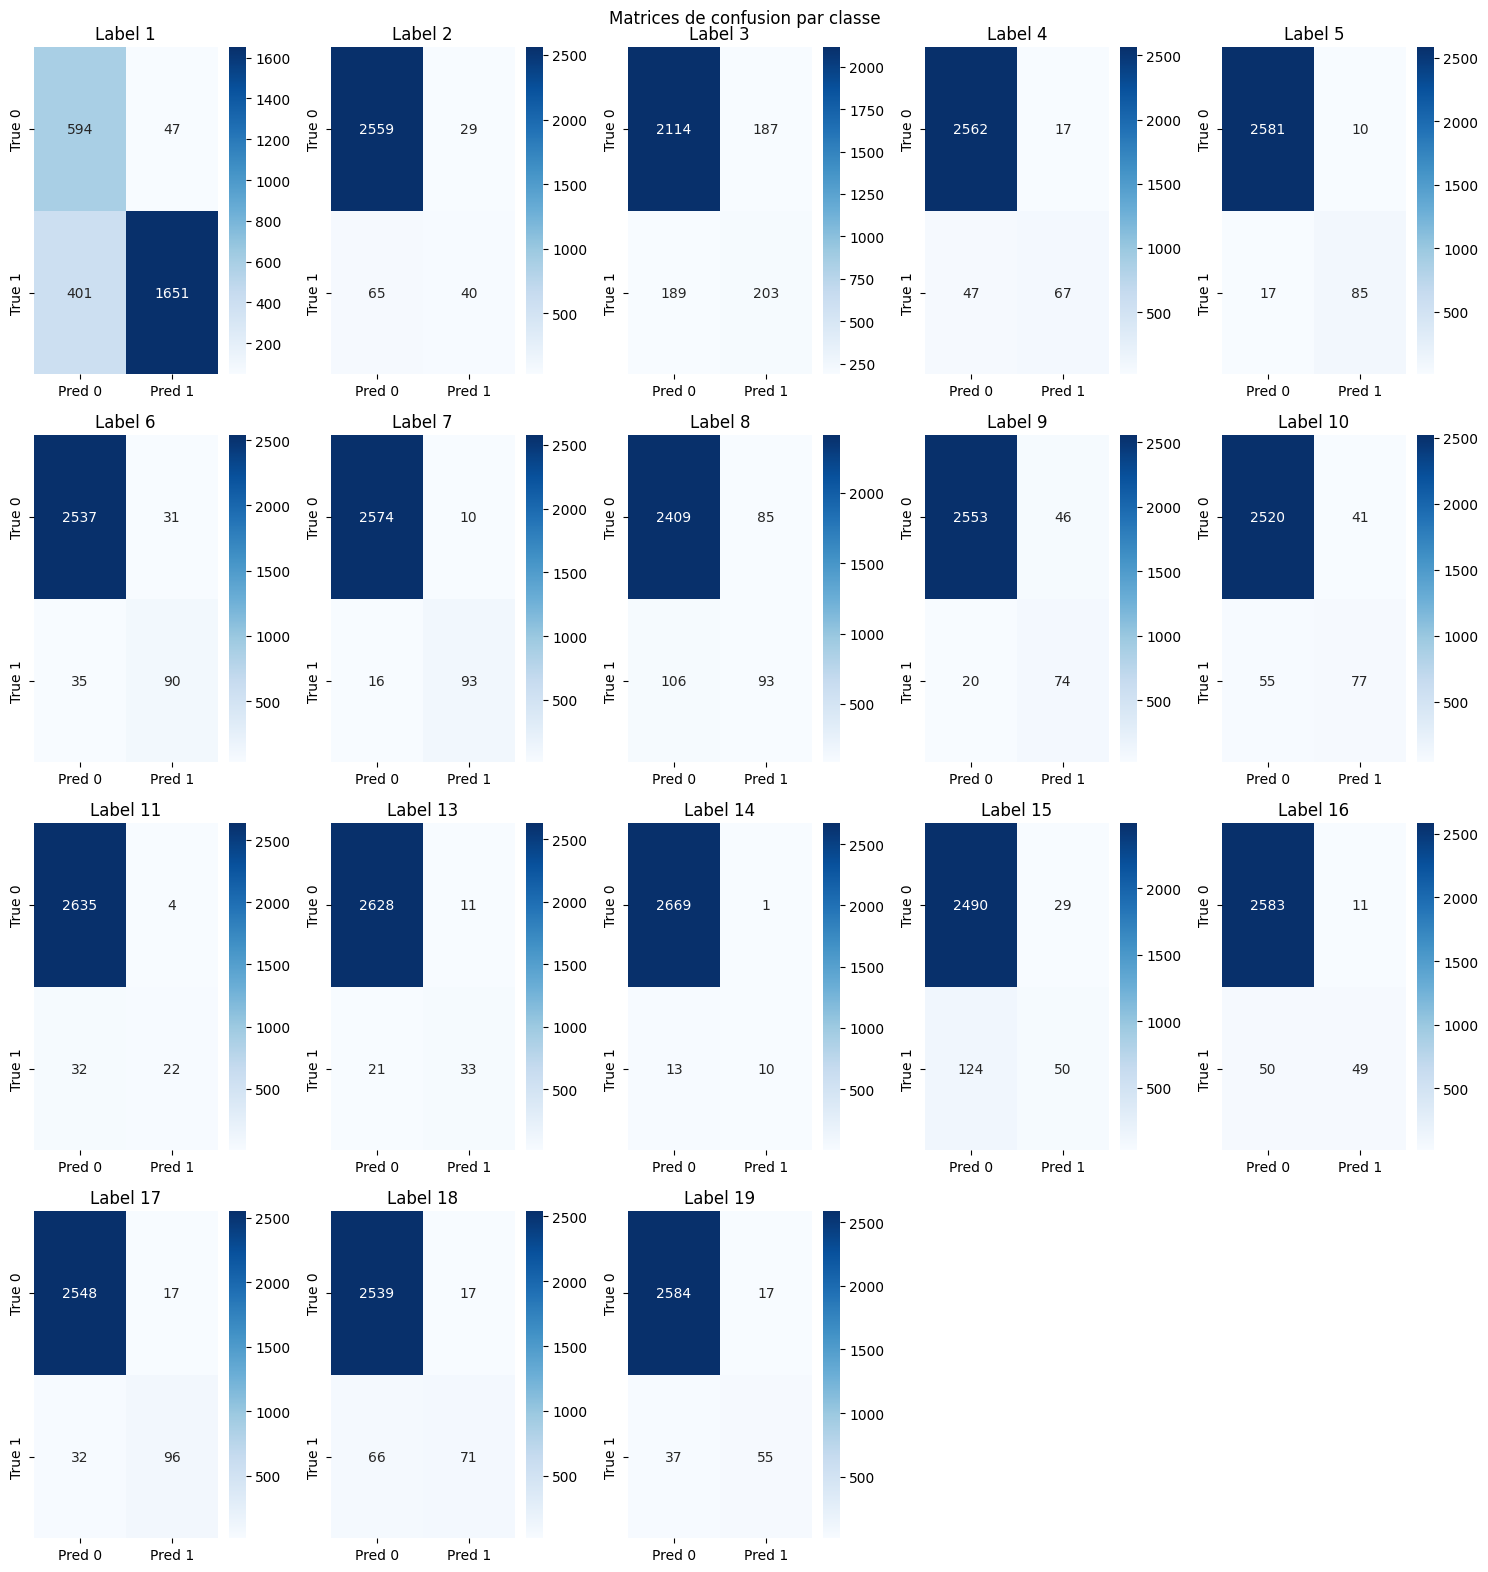

In [ ]:
plot_confusion_matrices(y_val, y_pred_optimized, n_labels=18)

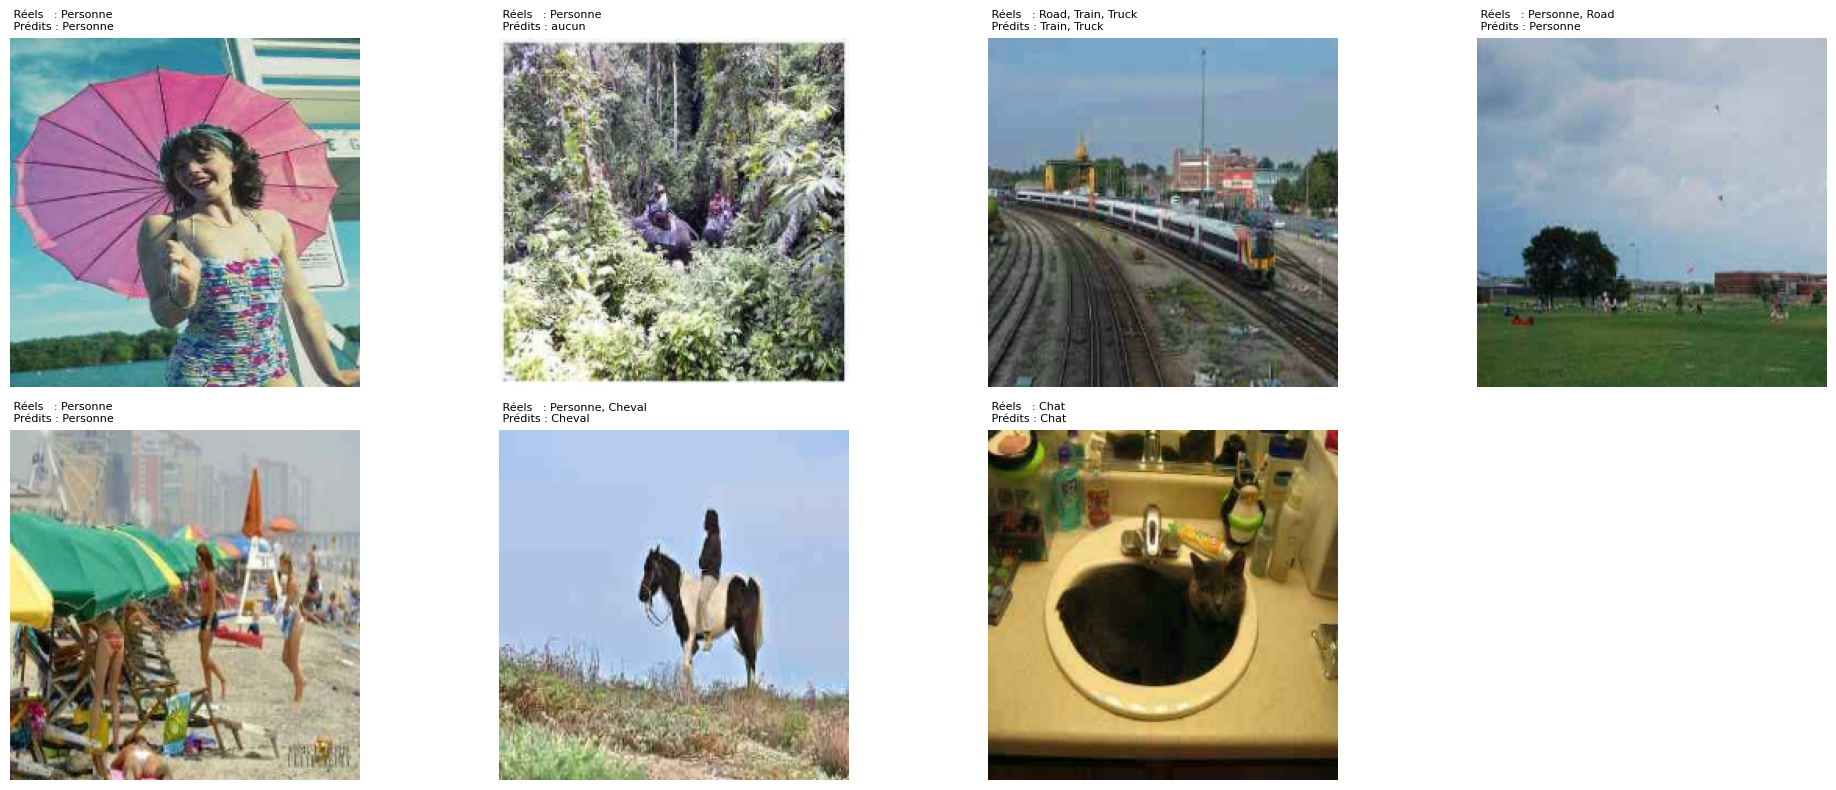

In [ ]:
plot_predictions_custom_seuils([0,1,2,3,5,15,18], val_ds, y_pred_optimized, best_thresholds)

In [ ]:
efficient_model.save("model_image_final.keras")


print("Sauvegarde terminée.")

Sauvegarde terminée.


# Explicabilité du modèle

L’explicabilité du modèle est étudiée à l’aide de la méthode **LIME** (Local Interpretable Model-agnostic Explanations). Cette approche consiste à segmenter l’image en superpixels, puis à identifier ceux qui influencent positivement ou négativement les prédictions du modèle.

LIME permet ainsi de visualiser les zones de l’image sur lesquelles le modèle s’appuie pour prendre ses décisions, offrant une interprétation locale de ses prédictions.

In [ ]:
!pip install lime scikit-image

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 8.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=6453d4561749da56242048b4a9189cb17416bcd3b48d03ff1253d76c629a5534
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [ ]:
idx = 0
image_id  = df_val["ImageID"].iloc[idx]
image_np  = load_image_for_lime(image_id, data_dir)

true_labels = labels_to_vector(df_val["Labels"].iloc[idx])
img_tensor  = tf.expand_dims(tf.cast(image_np, tf.float32), axis=0)
pred_probs  = efficient_model.predict(img_tensor, verbose=0)[0]
pred_labels = (pred_probs >= 0.3).astype(int)

print(f"Image ID          : {image_id}")
print(f"Labels réels      : {true_labels}")
print(f"Labels prédits    : {pred_labels}")
print(f"Probabilités      : {pred_probs.round(2)}")

Image ID          : 0.jpg
Labels réels      : [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Labels prédits    : [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
Probabilités      : [0.96 0.14 0.07 0.   0.   0.01 0.   0.07 0.25 0.01 0.   0.03 0.   0.08
 0.   0.01 0.04 0.  ]



→ Label 1 | prob=0.96 | vrai label=1.0


  0%|          | 0/1000 [00:00<?, ?it/s]

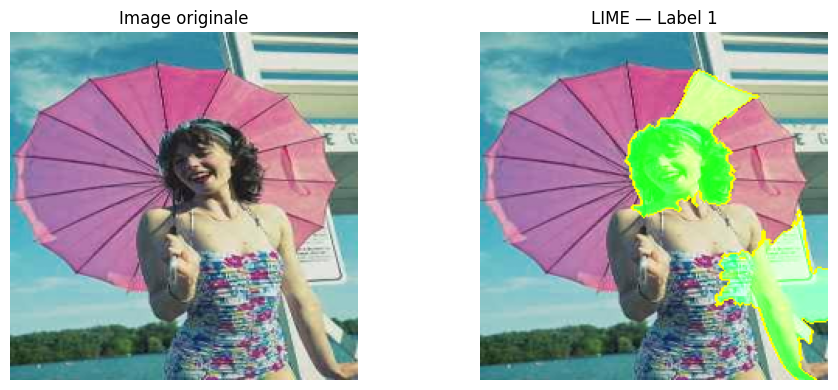

In [ ]:
explain_all_active_labels(image_np, true_labels, pred_probs)

LIME met en évidence le visage et le corps de la personne comme régions déterminantes pour la prédiction du Label 1. C'est un comportement cohérent.

In [ ]:
idx = 0
image_id  = df_val["ImageID"].iloc[idx]
image_np  = load_image_for_lime(image_id, data_dir)

true_labels = labels_to_vector(df_val["Labels"].iloc[idx])
img_tensor  = tf.expand_dims(tf.cast(image_np, tf.float32), axis=0)
pred_probs  = efficient_model.predict(img_tensor, verbose=0)[0]
pred_labels = (pred_probs >= 0.3).astype(int)